In [5]:
import pandas as pd
import numpy as ap
import matplotlib.pyplot as plt

In [6]:
df_features = pd.read_csv("D:\\side project\\secom\\secom.data", 
                          sep = " ",
                          header = None)
df_labels = pd.read_csv("D:\\side project\\secom\\secom_labels.data",
                        sep = " ",
                        header = None)

In [7]:
print("Dim of feature matrix", df_features.shape)
print("Dim of labels matrix", df_labels.shape)

Dim of feature matrix (1567, 590)
Dim of labels matrix (1567, 2)


In [8]:
df_features.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [9]:
df_labels.head()

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [10]:
df_labels.columns = ["Yield_Label", "Time_Stamp"]
df_labels

,Yield_Label,Time_Stamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00
...,...,...
1562,-1,16/10/2008 15:13:00
1563,-1,16/10/2008 20:49:00
1564,-1,17/10/2008 05:26:00
1565,-1,17/10/2008 06:01:00


In [11]:
len(df_labels[df_labels["Yield_Label"]>0])/1567*100

6.636885768985322

In [12]:
#  Step 1: 移除常數特徵 

In [13]:
# 計算每個欄位有幾種獨立的數值
unique_counts = df_features.nunique()   #len(df_features.loc[:,0].value_counts()
unique_counts

0      1520
1      1504
2       507
3       518
4       503
       ... 
585    1502
586     322
587     260
588     120
589     611
Length: 590, dtype: int64

In [14]:
# 找出不重複數值只有 1 種的欄位名稱 (即常數特徵)
constant_counts = unique_counts[unique_counts == 1].index
constant_counts

Index([  5,  13,  42,  49,  52,  69,  97, 141, 149, 178,
       ...
       529, 530, 531, 532, 533, 534, 535, 536, 537, 538],
      dtype='int64', length=116)

In [15]:
print(f"1. 發現常數特徵有{len(constant_counts)}個")

1. 發現常數特徵有116個


In [16]:
# 剔除常數特徵
df_feature_clean = df_features.drop(constant_counts, axis = "columns")
df_feature_clean


,0,1,2,3,4,6,7,8,9,10,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,NaN,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [17]:
print(f"剔除常數特徵之矩陣維度 : {df_feature_clean.shape}")

剔除常數特徵之矩陣維度 : (1567, 474)


In [18]:
#Step 2: 處理 NaN 缺失值 

In [19]:
# 計算剩餘每個欄位的缺失值總數
nan_counts = df_feature_clean.isna().sum()
nan_counts

0       6
1       7
2      14
3      14
4      14
       ..
585     1
586     1
587     1
588     1
589     1
Length: 474, dtype: int64

In [20]:
# 設定閥值：缺失值超過資料筆數的 50% 即判定為嚴重損壞 (1567 * 0.5)
threshold = len(df_feature_clean)*0.5
threshold

783.5

In [21]:
bad_columns = nan_counts[nan_counts>threshold].index
bad_columns

Index([ 72,  73,  85, 109, 110, 111, 157, 158, 220, 244, 245, 246, 292, 293,
       345, 346, 358, 382, 383, 384, 492, 516, 517, 518, 578, 579, 580, 581],
      dtype='int64')

In [22]:
df_features_clean = df_feature_clean.drop(bad_columns, axis = "columns")
df_features_clean

,0,1,2,3,4,6,7,8,9,10,...,576,577,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,1.4879,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,1.0187,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,NaN,NaN,NaN,...,1.2237,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,1.7085,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [23]:
df_features_clean = df_features_clean.fillna(df_features_clean.median())
df_features_clean

,0,1,2,3,4,6,7,8,9,10,...,576,577,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,1.4879,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,1.0187,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,1.4616,-0.0013,0.0004,...,1.2237,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,1.7085,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [24]:
print(f" 剔除並填補後的乾淨矩陣維度為 {df_features_clean.shape}")
print(f" 檢查矩陣中剩餘的NAN數為 {df_features_clean.isna().sum().sum()}")
print(f"1. 發現常數特徵有 {len(constant_counts)}個")
print(f"2. 發現嚴重損壞特徵有 {len(bad_columns)}個")

 剔除並填補後的乾淨矩陣維度為 (1567, 446)
 檢查矩陣中剩餘的NAN數為 0
1. 發現常數特徵有 116個
2. 發現嚴重損壞特徵有 28個


In [25]:
## 相關性分析與 SPC 預警 (第一部分)

In [26]:
df_features_clean = pd.concat([df_features_clean, df_labels["Yield_Label"]], axis = 1) 
df_features_clean 

,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,Yield_Label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,1.4616,-0.0013,0.0004,...,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1


In [27]:
#  計算 Pearson 相關係數
correlation_matrix = df_features_clean.corr()
correlation_matrix

,0,1,2,3,4,6,7,8,9,10,...,577,582,583,584,585,586,587,588,589,Yield_Label
0,1.000000,-0.144161,0.004667,-0.006665,-0.010819,0.002028,0.031347,-0.052735,0.009091,0.006445,...,0.008639,0.000190,0.023562,0.019994,0.023695,0.018534,-0.025867,-0.028161,0.004185,-0.025100
1,-0.144161,1.000000,0.005883,-0.008963,-0.001917,-0.025222,-0.011761,0.031244,0.024025,0.009529,...,-0.010156,0.043754,0.002863,-0.001305,0.002231,-0.009430,0.017056,0.009868,0.044552,-0.002542
2,0.004667,0.005883,1.000000,0.298810,0.095881,-0.136212,-0.147116,0.023524,0.016248,0.069902,...,-0.028737,-0.005971,0.015694,0.018224,0.015749,-0.025506,-0.029287,-0.030743,-0.032763,-0.000999
3,-0.006665,-0.008963,0.298810,1.000000,-0.058351,-0.685773,0.086965,-0.102839,0.066987,0.049785,...,0.016888,0.008305,0.025288,0.024615,0.025882,0.035164,-0.039196,-0.033755,-0.080942,-0.024014
4,-0.010819,-0.001917,0.095881,-0.058351,1.000000,-0.074395,-0.343413,-0.025933,0.053973,-0.006496,...,-0.003978,0.044943,-0.001331,-0.001621,-0.001645,-0.043831,-0.031012,-0.026115,0.050792,-0.013633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,0.018534,-0.009430,-0.025506,0.035164,-0.043831,-0.041299,0.058019,0.010418,0.033700,0.000329,...,-0.002678,-0.016729,0.002258,0.001603,0.002745,1.000000,0.167920,0.164247,-0.486530,0.004170
587,-0.025867,0.017056,-0.029287,-0.039196,-0.031012,0.034113,-0.021518,0.022793,0.059181,0.046995,...,-0.009388,-0.024507,-0.002566,-0.002442,-0.002848,0.167920,1.000000,0.974276,0.390834,0.035423
588,-0.028161,0.009868,-0.030743,-0.033755,-0.026115,0.032341,-0.020936,0.026185,0.060609,0.046083,...,-0.015575,-0.020743,-0.002172,-0.001900,-0.002444,0.164247,0.974276,1.000000,0.389238,0.031207
589,0.004185,0.044552,-0.032763,-0.080942,0.050792,0.044039,-0.107904,-0.022864,0.004670,0.008462,...,-0.024740,0.041449,-0.002928,-0.003246,-0.003722,-0.486530,0.390834,0.389238,1.000000,-0.002603


In [28]:
# 只關心 感測器 跟 良率 (Yield_Label)之間的相關性
label_correlations = correlation_matrix['Yield_Label'].drop('Yield_Label')
label_correlations

0     -0.025100
1     -0.002542
2     -0.000999
3     -0.024014
4     -0.013633
         ...   
585    0.005049
586    0.004170
587    0.035423
588    0.031207
589   -0.002603
Name: Yield_Label, Length: 446, dtype: float64

In [95]:
top_5_features = label_correlations.abs().sort_values(ascending = False).head()
print("=== Top 5 影響良率的戰犯參數 (Pearson 相關係數絕對值) ===")
print(top_5_features)

=== Top 5 影響良率的戰犯參數 (Pearson 相關係數絕對值) ===
59     0.156008
103    0.151230
510    0.131662
348    0.130807
431    0.119936
Name: Yield_Label, dtype: float64


In [30]:
## 針對 TOP1 做 3sigma運算
top1_feature = top_5_features.index[0]
target_data = df_features_clean[top1_feature]
top1_mean = target_data.mean()
top1_std = target_data.std()
UCL = top1_mean + 3*top1_std
LCL = top1_mean - 3*top1_std
print(f"平均值 (Mean): {top1_mean:.4f}")
print(f"標準差 (Std): {top1_std:.4f}")
print(f"UCL (+3 Sigma): {UCL:.4f}")
print(f"LCL (-3 Sigma): {LCL:.4f}")
outlier = (target_data>UCL) | (target_data<LCL)
outlier_counts = outlier.sum()
print(f"在這個感測器上，共有{outlier_counts}片晶圓突破管制線。")

平均值 (Mean): 2.9512
標準差 (Std): 9.5118
UCL (+3 Sigma): 31.4868
LCL (-3 Sigma): -25.5843
在這個感測器上，共有5片晶圓突破管制線。


In [86]:
## 對 TOP5 做 3sigma運算
outlier_summary = {}
chip_summary = pd.Series({})
print("=== Top 5 參數 3-Sigma 異常觸發統計 ===")
for feature in top_5_features.index:
    target_data = df_features_clean[feature]
    mean = target_data.mean()
    std = target_data.std()
    UCL = mean + 3*std
    LCL = mean - 3*std
    outlier = (target_data>UCL) | (target_data<LCL)
    outlier_counts = outlier.sum()
    outlier_summary[feature] = outlier_counts
    chip_summary = pd.concat([chip_summary, outlier[outlier == True]])
    print(f"在{feature}感測器上，共有{outlier_counts}片晶圓突破管制線。")
chip = pd.Series(chip_summary.index)
print(f"\n以下晶圓為異常\n{chip.unique()} \n有{len(chip.unique())}個");

=== Top 5 參數 3-Sigma 異常觸發統計 ===
在59感測器上，共有5片晶圓突破管制線。
在103感測器上，共有7片晶圓突破管制線。
在510感測器上，共有32片晶圓突破管制線。
在348感測器上，共有24片晶圓突破管制線。
在431感測器上，共有32片晶圓突破管制線。

以下晶圓為異常
[ 275  421  457  466  634  219  484  580  689  856 1151 1519    2   15
   19   38   54   61   72  120  123  161  170  175  184  189  214  240
  248  317  345  603  702  732  769  998 1124 1227 1444   68  254  313
  320  321  327  330  331  349  366  367  378  412  587  618  880  925
 1033 1052 1117 1134 1242 1292 1400    8   10   14   23   24   25   33
   36   44   46   47   51   57   58   84   91   93   96   99  143  144
  163  172  183  186  195  196  800] 
有91個


In [88]:
outlier_summary = {}
combined_outlier = pd.Series(False, index = df_feature_clean.index)
print("=== Top 5 參數 3-Sigma 異常觸發統計 ===")
for feature in top_5_features.index:
    target_data = df_features_clean[feature]
    mean = target_data.mean()
    std = target_data.std()
    UCL = mean + 3*std
    LCL = mean - 3*std
    outlier = (target_data>UCL) | (target_data<LCL)
    outlier_counts = outlier.sum()
    outlier_summary[feature] = outlier_counts
    combined_outlier = combined_outlier | outlier
    print(f"在{feature}感測器上，共有{outlier_counts}片晶圓突破管制線。")
unique_outlier_count = combined_outlier.sum()
print(f"經過聯集去重疊後，實際抓到的『獨特異常晶圓』總數為: {unique_outlier_count} 片")

=== Top 5 參數 3-Sigma 異常觸發統計 ===
在59感測器上，共有5片晶圓突破管制線。
在103感測器上，共有7片晶圓突破管制線。
在510感測器上，共有32片晶圓突破管制線。
在348感測器上，共有24片晶圓突破管制線。
在431感測器上，共有32片晶圓突破管制線。
經過聯集去重疊後，實際抓到的『獨特異常晶圓』總數為: 91 片


In [ ]:
## 實證：SPC 警報與真實良率的交集比對

In [92]:
actual_fails = (df_labels["Yield_Label"] == 1)
# 全部真實壞品數
total_actual_fails = actual_fails.sum()
true_positives = actual_fails & combined_outlier
# 真正命中壞品數
hit_count = true_positives.sum()
# 未命中壞品數
false_negetive = total_actual_fails - hit_count
# 誤殺的好品數
false_positive = unique_outlier_count - hit_count


recall_rate = hit_count / total_actual_fails

print(f"1. 系統總共攔截了: {unique_outlier_count} 片晶圓 ")
print(f"2. 其中真正命中的壞品 (True Positives): {hit_count} 片")
print(f"3. 誤殺的無辜好品 (False Positives / Overkill): {false_positive} 片")
print(f"4. 防線抓漏率 (Recall): {recall_rate * 100:.2f}% (命中了 {hit_count} / {total_actual_fails})")


1. 系統總共攔截了: 91 片晶圓 
2. 其中真正命中的壞品 (True Positives): 19 片
3. 誤殺的無辜好品 (False Positives / Overkill): 72 片
4. 防線抓漏率 (Recall): 18.27% (命中了 19 / 104)


In [ ]:
##  Visualization

In [ ]:
import matplotlib.pyplot as plt

In [165]:
## preparation for plotting
data_top5 = pd.DataFrame({})
target_data_save = pd.DataFrame({})
for feature in top_5_features.index:
    target_data = df_features_clean[feature]
    target_data_save[feature] =df_features_clean[feature]
    mean = target_data.mean()
    std = target_data.std()
    UCL = mean + 3*std
    LCL = mean - 3*std
    statistic = pd.DataFrame([[mean, std, UCL, LCL]], 
                             index = [feature],
                             columns = ["mean", "std", "UCL", "LCL"])
    data_top5 = pd.concat([data_top5,statistic])

print(f"target_data_save: \n{target_data_save}")
print(f"statisitc of targrt_data: \n{data_top5}")


target_data_save: 
          59      103       510     348      431
0     -1.7264 -0.0042   64.6707  0.0215  33.1562
1      0.8073 -0.0045  141.4365  0.0142   2.2655
2     23.8245 -0.0026  240.7767  0.0105  29.1663
3     24.3791 -0.0059  113.5593  0.0407  13.4051
4    -12.2945 -0.0045  148.0663  0.0246  10.7390
...       ...     ...       ...     ...      ...
1562   2.8182 -0.0094   53.1915  0.0226  12.8067
1563  -3.3555 -0.0116   29.4372  0.0226   4.1273
1564   1.1664 -0.0142   54.8330  0.0226  20.0222
1565   4.4682 -0.0087   78.4993  0.0226   9.4153
1566   1.8718 -0.0102   75.8621  0.0226  11.3943

[1567 rows x 5 columns]
statisitc of targrt_data: 
          mean        std         UCL        LCL
59    2.951249   9.511839   31.486767 -25.584268
103  -0.009789   0.003063   -0.000602  -0.018977
510  55.752306  37.668964  168.759196 -57.254585
348   0.024673   0.011774    0.059996  -0.010649
431  22.350676  36.372786  131.469033 -86.767681


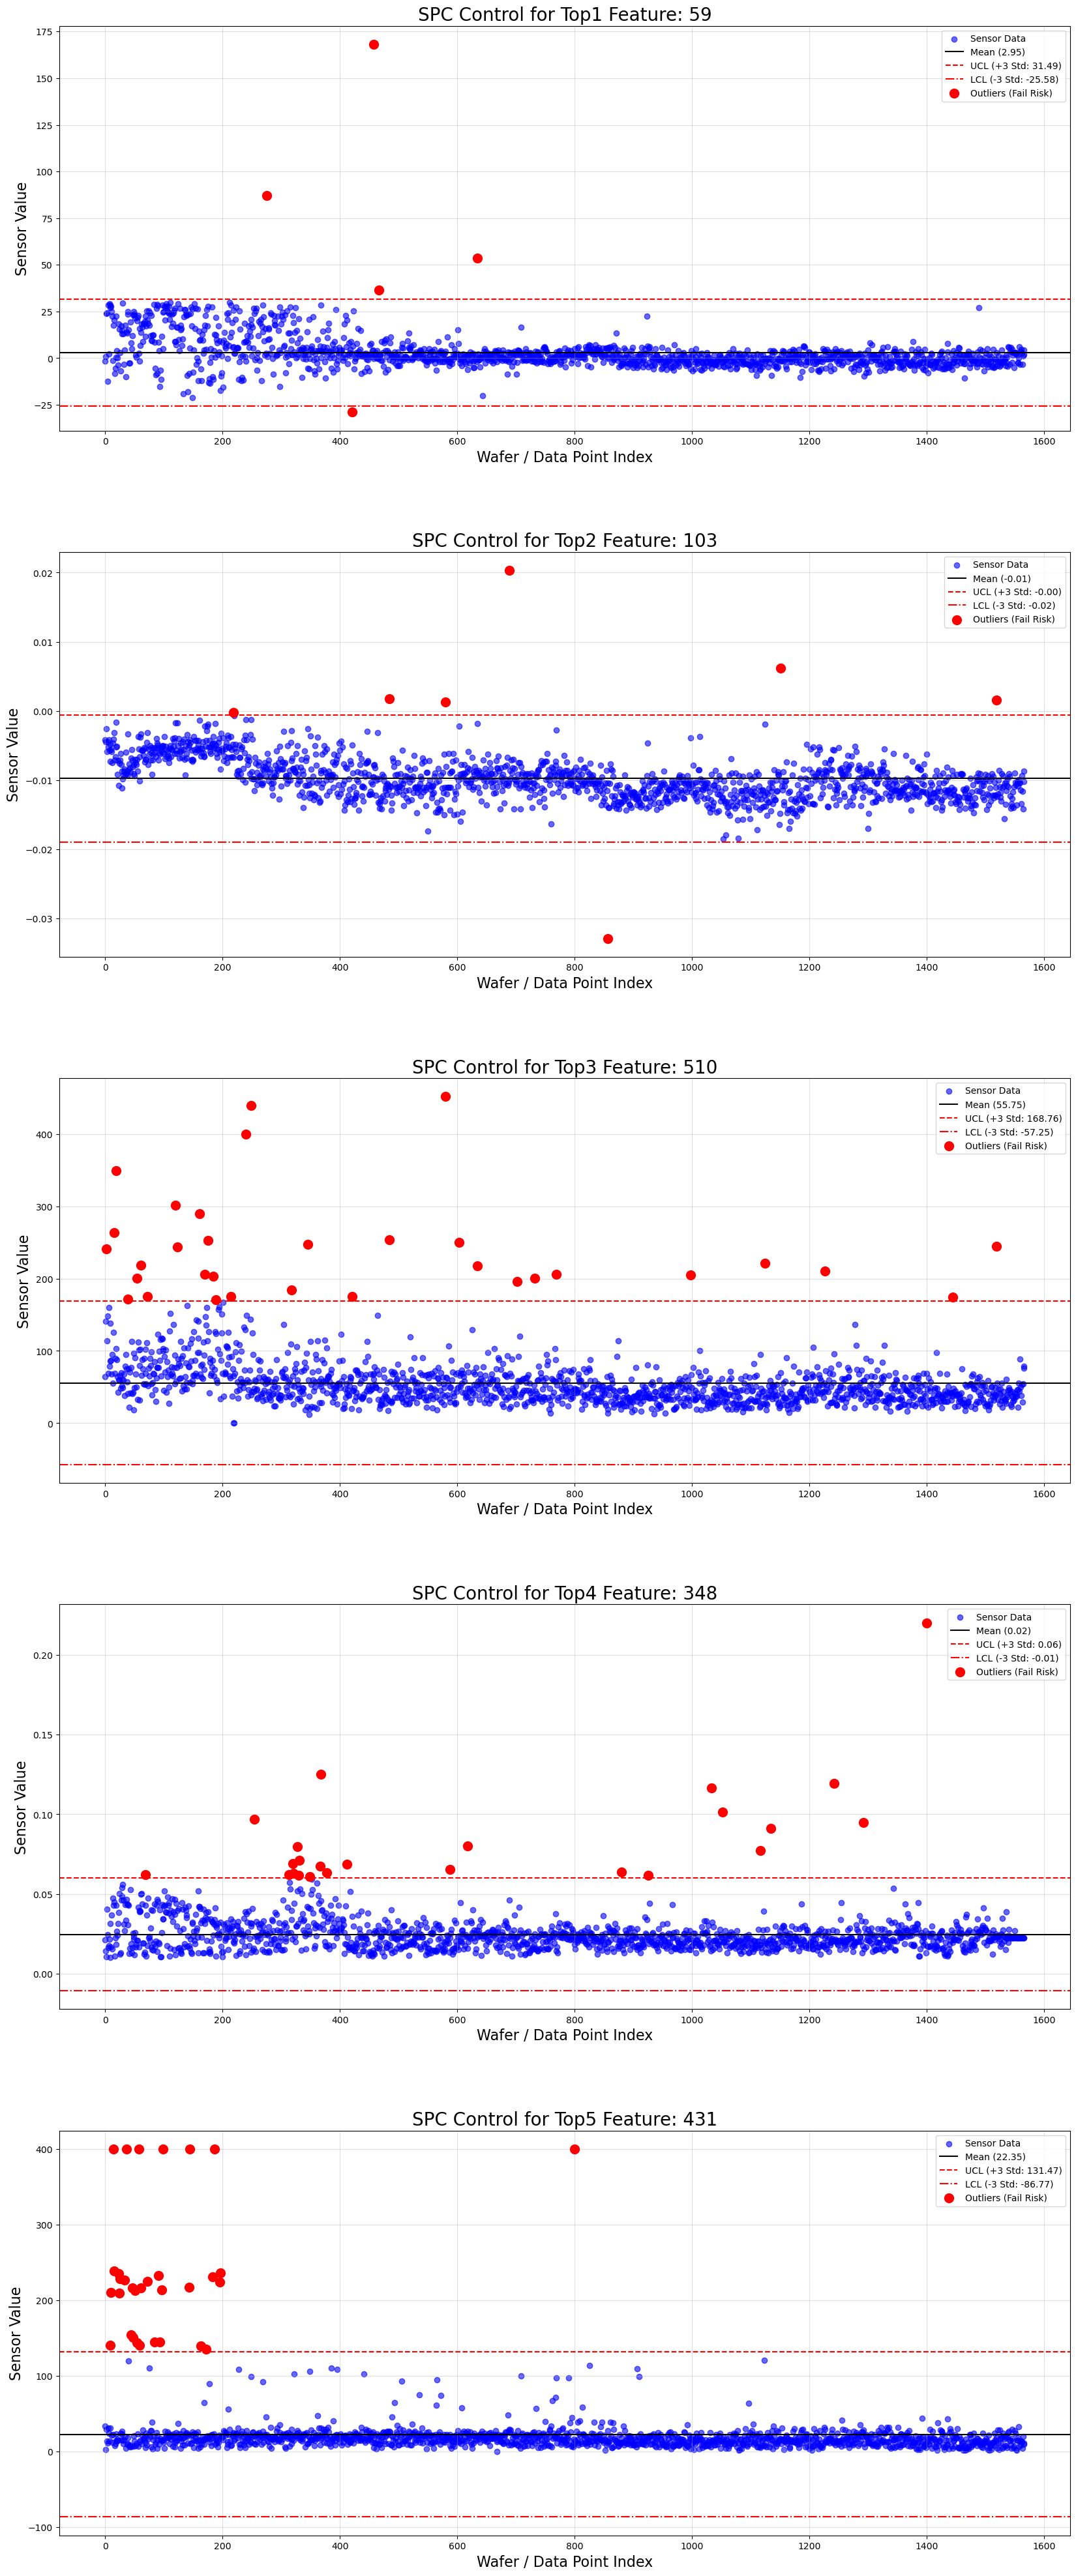

In [198]:
fig, ax = plt.subplots(5,1, figsize =(20,50))
fig.subplots_adjust(wspace=0.3, hspace=0.3)


for i in range(5):
    t = target_data_save.iloc[:,i]
    Mean = data_top5.iloc[i,0]
    UCL = data_top5.iloc[i,2]
    LCL = data_top5.iloc[i,3]
    ax[i].scatter(target_data.index, t,
                  label = f"Sensor Data ", color = "blue", alpha = 0.6
                  )
    ax[i].axhline(Mean, color='black',
                  linestyle='-', label=f"Mean ({Mean:.2f})")
    ax[i].axhline(UCL, color='red',
                  linestyle='--', label=f"UCL (+3 Std: {UCL:.2f})")
    ax[i].axhline(LCL, color='red',
                  linestyle='-.', label=f"LCL (-3 Std: {LCL:.2f})")
    outlier = t[ (t > data_top5.iloc[i,2]) | (t < data_top5.iloc[i,3]) ]
    
    ax[i].scatter(outlier.index, outlier, 
                  color = "red", s=100, 
                  label='Outliers (Fail Risk)', zorder=5)
    ax[i].legend()
    ax[i].set_title(f"SPC Control for Top{i+1} Feature: {data_top5.index[i]}", fontsize=20)
    ax[i].set_xlabel("Wafer / Data Point Index", fontsize=16)
    ax[i].set_ylabel("Sensor Value", fontsize=16)
    ax[i].grid(True, alpha=0.4)
plt.savefig('Top5_SPC_Control_Chart.png', dpi=300, bbox_inches='tight')